## Exploratory Data Analysis

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from geopy.distance import geodesic

In [80]:
df = pd.read_parquet("base_consolidada_logistica.parquet")

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  str           
 5   order_delivered_carrier_date   111456 non-null  str           
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  112650 non-null  datetime64[us]
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  str           
 10  seller_id                      112650 non-null  str           
 11  shipping_li

In [82]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,payment_type_main,seller_geo_city,seller_geo_state,customer_geo_city,customer_geo_state,seller_customer_distance_km,is_late,product_volume_cm3
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,voucher,maua,SP,sao paulo,SP,18.566632,0,1976.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,boleto,belo horizonte,MG,barreiras,BA,847.437333,0,4693.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,credit_card,guariba,SP,vianopolis,GO,512.100044,0,9576.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,10.0,20.0,credit_card,belo horizonte,MG,sao goncalo do amarante,RN,1816.085655,0,6000.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,15.0,15.0,credit_card,mogi das cruzes,SP,santo andre,SP,29.684401,0,11475.0


In [83]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,112650,98666,fc3d1daec319d62d49bfb5e1f83123e9,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,112650,7,delivered,110197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,112650,NaN,NaN,NaN,2018-01-01 00:09:48.464376,2016-09-04 21:15:19,2017-09-13 19:17:04,2018-01-19 23:02:16,2018-05-04 17:30:36.750000,2018-09-03 09:06:57,NaN
order_approved_at,112635,90174,2018-02-24 03:20:27,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,111456,81017,2018-05-09 15:48:00,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,110196,NaN,NaN,NaN,2018-01-14 13:25:24.023939,2016-10-11 13:46:32,2017-09-26 20:09:44.500000,2018-02-02 20:57:23,2018-05-15 20:09:21.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,112650,NaN,NaN,NaN,2018-01-24 20:12:15.531291,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
order_item_id,112650.0,NaN,NaN,NaN,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
#Getting an idea of how much are the late orders.
df["is_late"].value_counts(dropna=False, normalize=True) 

is_late
0       0.900852
1       0.077364
<NA>    0.021784
Name: proportion, dtype: Float64

In [85]:
#Analysing Nulls
nulls = df.isna().mean().sort_values(ascending=False)
nulls[nulls > 0].head(30)

review_comment_message           0.579139
order_delivered_customer_date    0.021784
is_late                          0.021784
product_category_name            0.014230
order_delivered_carrier_date     0.010599
review_score                     0.008362
seller_customer_distance_km      0.004918
customer_geo_city                0.002681
customer_geo_state               0.002681
seller_geo_city                  0.002246
seller_geo_state                 0.002246
product_width_cm                 0.000160
product_height_cm                0.000160
product_length_cm                0.000160
product_weight_g                 0.000160
product_volume_cm3               0.000160
order_approved_at                0.000133
payment_type_main                0.000027
dtype: float64

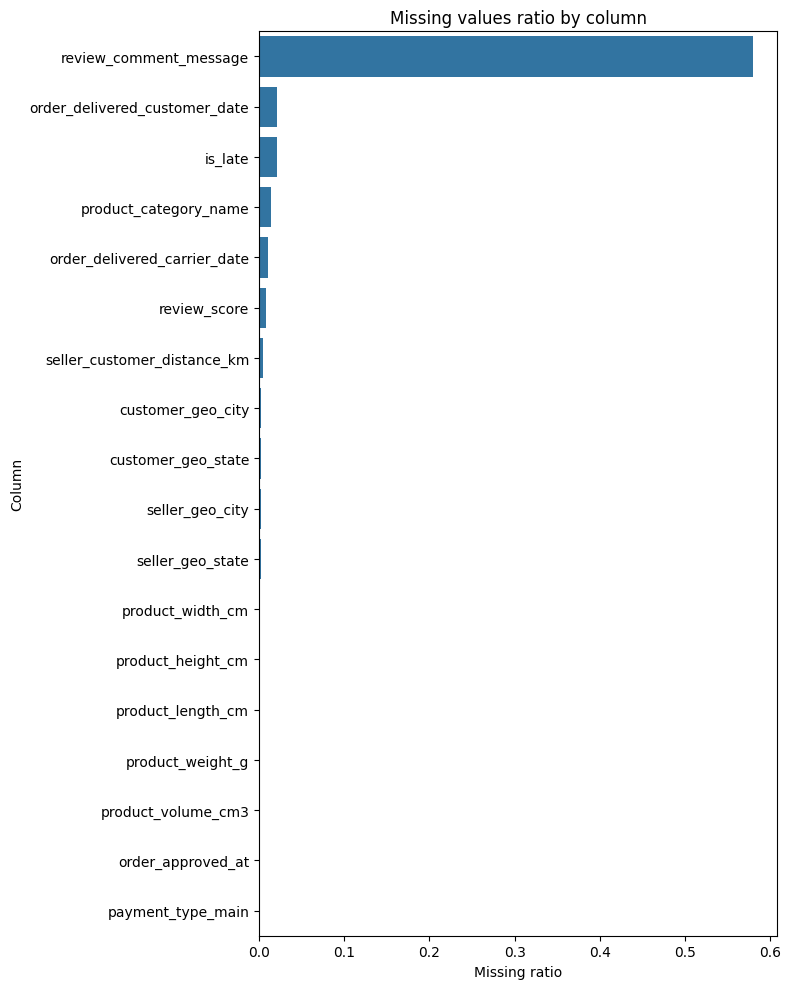

In [86]:
# Plot null ratios
plt.figure(figsize=(8, 10))
sns.barplot(x=nulls[nulls > 0], y=nulls[nulls > 0].index)
plt.title("Missing values ratio by column")
plt.xlabel("Missing ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Missing values - main observations:

- Some columns have a non‑negligible proportion of missing values, especially date fields related to delivery and review text fields.
- Columns with missing values are mostly expected (e.g. orders not delivered or without reviews), so they are likely informative rather than random noise.
- There are no columns with an extremely high null ratio that would be immediate candidates for dropping at this stage.
- We will need to handle missing values carefully during feature engineering, possibly with separate indicators (flags) for “missing” where it makes business sense.

In [87]:
# Derive delivery time columns to enhance features

df["actual_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days

df["delay_vs_estimated_days"] = (
    df["actual_delivery_days"] - df["estimated_delivery_days"]
)

In [88]:
# Descriptive statistics for delivery times
df[["actual_delivery_days", "estimated_delivery_days", "delay_vs_estimated_days"]].describe()

,actual_delivery_days,estimated_delivery_days,delay_vs_estimated_days
count,110196.000000,112650.000000,110196.000000
mean,12.007723,23.470484,-11.433446
std,9.451455,8.884872,10.170284
min,0.000000,2.000000,-146.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,189.000000


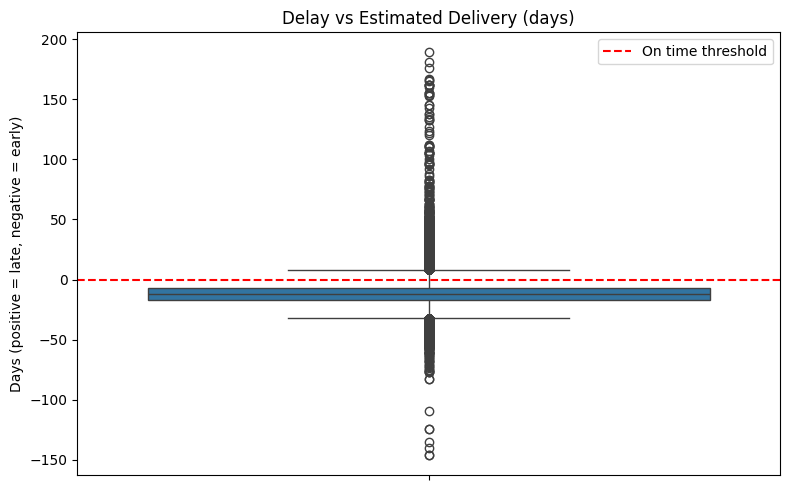

In [89]:
# Boxplot of delay vs estimated delivery days
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df[df["delay_vs_estimated_days"].notna()],
    y="delay_vs_estimated_days"
)
plt.axhline(0, color="red", linestyle="--", label="On time threshold")
plt.title("Delay vs Estimated Delivery (days)")
plt.ylabel("Days (positive = late, negative = early)")
plt.legend()
plt.tight_layout()
plt.show()

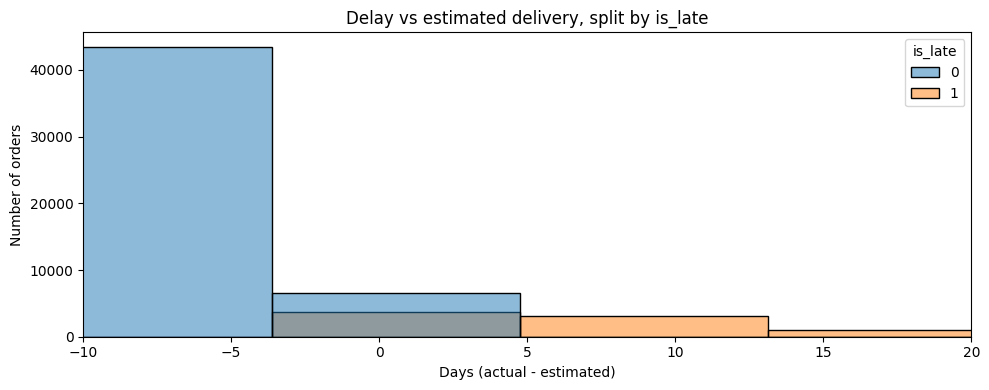

In [90]:
# Plot delay distribution split by is_late
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df[df["is_late"].notna()],
    x="delay_vs_estimated_days",
    hue="is_late",
    bins=40,
    kde=False,
    multiple="layer"
)
plt.xlim(-10, 20)
plt.title("Delay vs estimated delivery, split by is_late")
plt.xlabel("Days (actual - estimated)")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()

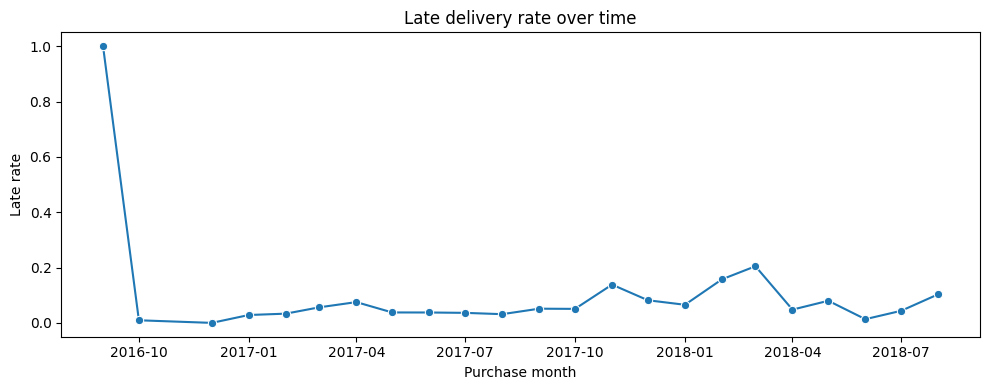

In [91]:
# Aggregate late rate by purchase month
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly = (
    df[df["is_late"].notna()]
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum()),
        ontime_orders=("is_late", lambda x: (x == 0).sum())
    )
)

monthly["late_rate"] = monthly["late_orders"] / (
    monthly["late_orders"] + monthly["ontime_orders"]
)
monthly.index = monthly.index.to_timestamp()

# Plot monthly late rate
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly, x=monthly.index, y="late_rate", marker="o")
plt.title("Late delivery rate over time")
plt.xlabel("Purchase month")
plt.ylabel("Late rate")
plt.tight_layout()
plt.show()

### Time series analysis – main findings:

- The `delay_vs_estimated_days` variable shows that many orders are delivered slightly before or very close to the estimated date, but there is a noticeable right tail of late deliveries.
- The histogram of `delay_vs_estimated_days` indicates that small positive delays (a few days) are relatively common, while very large delays are less frequent but still present.
- The boxplot split by `is_late` shows a clear separation between on‑time and late orders: late orders have a much higher median delay and a wider spread, which validates `delay_vs_estimated_days` as a strong candidate feature for the model.
- There is a peak of delays in an specific period between the end of 2017 and the firs trimester of 2018.

In [92]:
# Aggregate late rate by customer state
state_late = (
    df[df["is_late"].notna()]
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)

state_late["late_rate"] = state_late["late_orders"] / state_late["total_orders"]
state_late = state_late.sort_values("late_rate", ascending=False)

state_late

,total_orders,late_orders,late_rate
customer_state,,,
AL,397,103,0.259446
MA,717,163,0.227336
SE,335,61,0.18209
CE,1279,218,0.170446
PI,476,81,0.170168
BA,3256,504,0.154791
RJ,12353,1835,0.148547
TO,274,38,0.138686
PA,946,131,0.138478


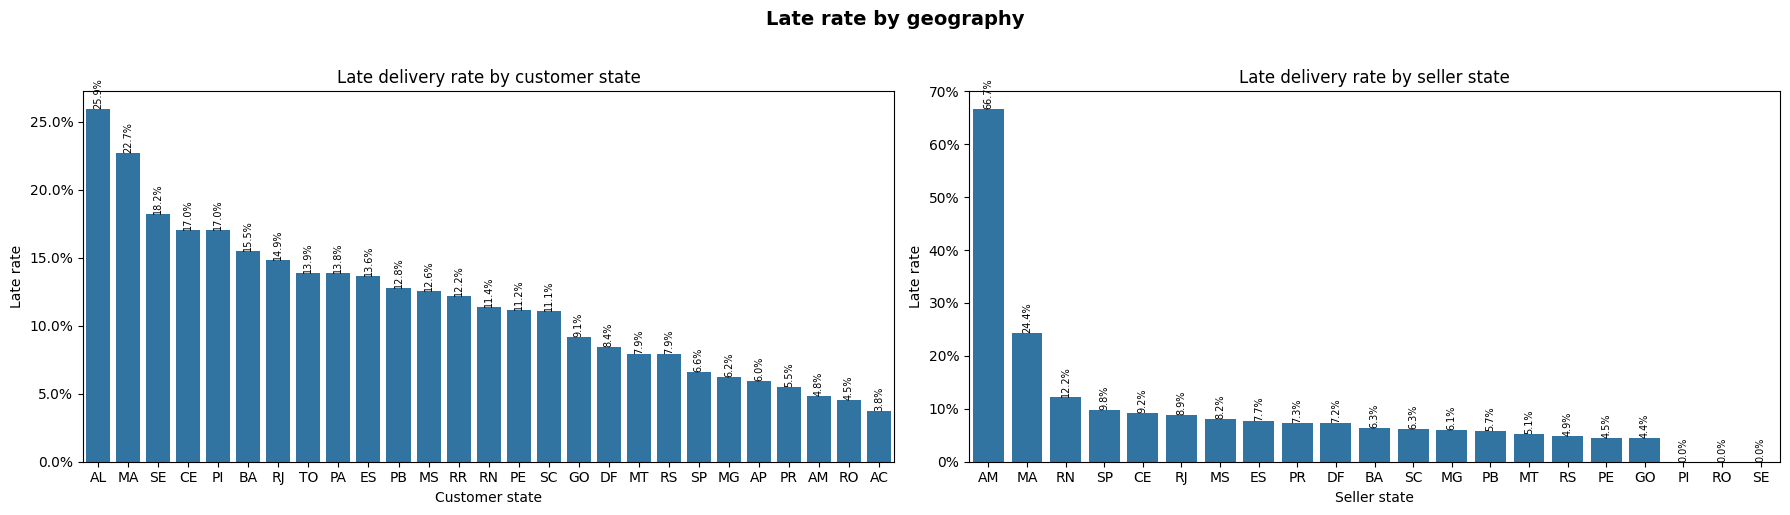

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Customer state ---
sns.barplot(
    data=state_late.reset_index(),
    x="customer_state",
    y="late_rate",
    order=state_late.index,
    ax=axes[0]
)

# Percentual annotations
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7, rotation=90
    )

axes[0].set_title("Late delivery rate by customer state")
axes[0].set_xlabel("Customer state")
axes[0].set_ylabel("Late rate")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# --- Seller state ---
seller_state_late = (
    df[df["is_late"].notna()]
    .groupby("seller_geo_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)
seller_state_late["late_rate"] = (
    seller_state_late["late_orders"] / seller_state_late["total_orders"]
)
seller_state_late = seller_state_late.sort_values("late_rate", ascending=False)

sns.barplot(
    data=seller_state_late.reset_index(),
    x="seller_geo_state",
    y="late_rate",
    order=seller_state_late.index,
    ax=axes[1]
)

# Percentual annotations
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7, rotation=90
    )

axes[1].set_title("Late delivery rate by seller state")
axes[1].set_xlabel("Seller state")
axes[1].set_ylabel("Late rate")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

plt.suptitle("Late rate by geography", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [94]:
# Creating function for distance calculation between customer and seller.

def compute_distance_km(row):
    # Se faltar qualquer coordenada, retornamos NaN
    if pd.isna(row["seller_geo_lat"]) or pd.isna(row["seller_geo_lng"]) \
       or pd.isna(row["customer_geo_lat"]) or pd.isna(row["customer_geo_lng"]):
        return pd.NA

    seller_coords = (row["seller_geo_lat"], row["seller_geo_lng"])
    customer_coords = (row["customer_geo_lat"], row["customer_geo_lng"])

    try:
        return geodesic(seller_coords, customer_coords).km
    except Exception:
        # Qualquer erro numérico ou coordenada estranha → NaN
        return pd.NA

# Isso pode ser um pouco pesado; use progress bar se quiser (tqdm)
df["seller_customer_distance_km"] = df.apply(compute_distance_km, axis=1)

KeyError: 'seller_geo_lat'

In [ ]:
df["seller_customer_distance_km"].describe()

count     112096.0
unique     93344.0
top            0.0
freq          26.0
Name: seller_customer_distance_km, dtype: float64

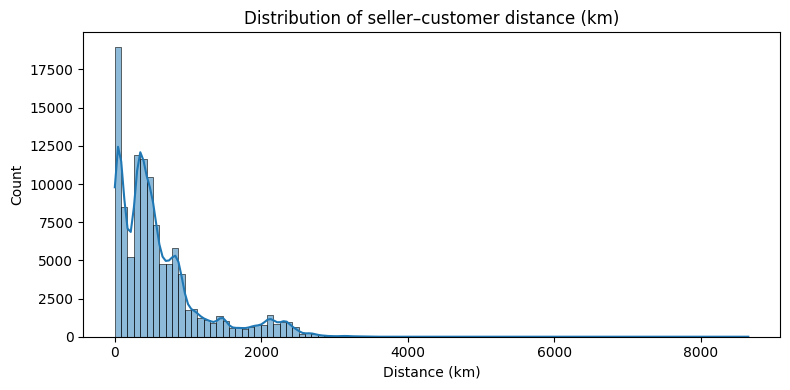

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="seller_customer_distance_km",
    bins=100,
    kde=True
)
plt.title("Distribution of seller–customer distance (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

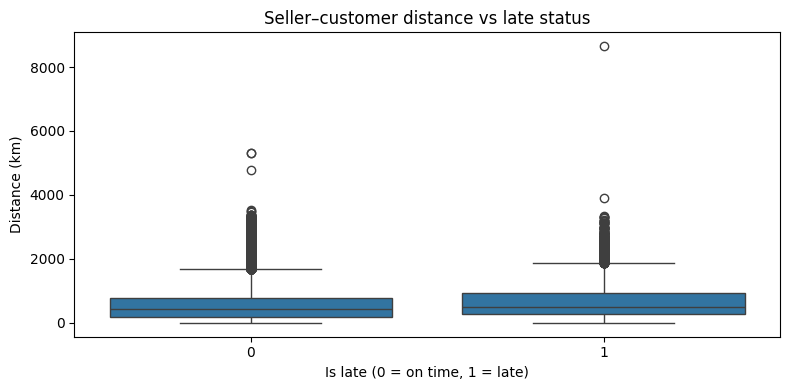

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="is_late",
    y="seller_customer_distance_km"
)
plt.title("Seller–customer distance vs late status")
plt.xlabel("Is late (0 = on time, 1 = late)")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

  distance_bucket_km  total_orders  late_rate
0             0–50km         13469     0.0663
1           50–200km         14704   0.060392
2          200–500km         34825   0.070007
3           500km–1k         29449   0.082516
4              1k–2k         11030   0.106346
5              2k–5k          6180   0.135922
6                5k+             3   0.333333


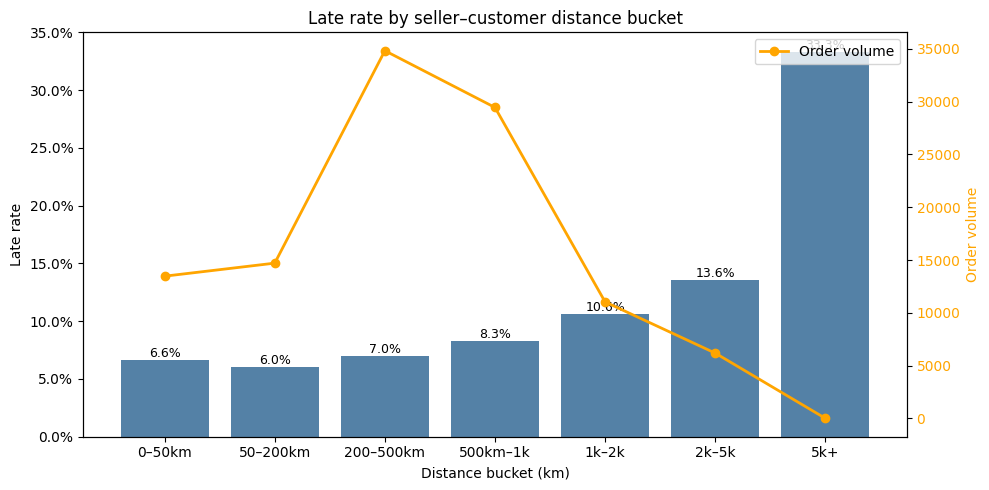

In [ ]:
# Filter out NA before bucketing
df_geo = df[df["is_late"].notna() & df["seller_customer_distance_km"].notna()].copy()

# Late rate by distance bucket
bins   = [0, 50, 200, 500, 1000, 2000, 5000, 10000]
labels = ["0–50km", "50–200km", "200–500km", "500km–1k", "1k–2k", "2k–5k", "5k+"]

df_geo["distance_bucket_km"] = pd.cut(
    df_geo["seller_customer_distance_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

distance_late = (
    df_geo
    .groupby("distance_bucket_km", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", lambda x: (x == 1).sum() / len(x))  # evita ambiguidade do NA
    )
    .reset_index()
)

print(distance_late)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=distance_late,
    x="distance_bucket_km",
    y="late_rate",
    color="steelblue",
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_title("Late rate by seller–customer distance bucket")
ax1.set_xlabel("Distance bucket (km)")
ax1.set_ylabel("Late rate")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    distance_late.index,
    distance_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Geolocation analysis – main findings:

- **Distance matters**: Although the boxplot indicates similar behavior in within late or not orders, the barplot shows that the distance between seller and customer has a clear relationship with late deliveries; larger distance buckets exhibit significantly higher late rates compared to local/regional deliveries.
- **Seller hotspot of delays**: the seller state with the highest late rate, by a wide margin, is **Amazonas (AM)**, suggesting relevant logistical challenges for shipments originating from this region.
- **Customer hotspots of delays**: customer states in the **Northeast** concentrate some of the highest late rates in the dataset, indicating potential bottlenecks in the delivery network to that region.
- These findings reinforce the importance of including **geography and seller–customer distance** as core features in the delay prediction model.

In [95]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id', 'customer_city',
       'customer_state', 'review_comment_message', 'review_score',
       'product_category_name', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'payment_type_main',
       'seller_geo_city', 'seller_geo_state', 'customer_geo_city',
       'customer_geo_state', 'seller_customer_distance_km', 'is_late',
       'product_volume_cm3', 'actual_delivery_days', 'estimated_delivery_days',
       'delay_vs_estimated_days', 'purchase_month'],
      dtype='str')

In [96]:
cols_size = [
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_volume_cm3",
    "product_weight_g",
    "is_late",
]

df_eda = df[cols_size].dropna(subset=["is_late"]).copy()
df_eda["is_late"] = df_eda["is_late"].astype(int)
df_eda.head()

,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,product_weight_g,is_late
0,19.0,8.0,13.0,1976.0,500.0,0
1,19.0,13.0,19.0,4693.0,400.0,0
2,24.0,19.0,21.0,9576.0,420.0,0
3,30.0,10.0,20.0,6000.0,450.0,0
4,51.0,15.0,15.0,11475.0,250.0,0


In [97]:
df_eda.groupby("is_late")[
    ["product_length_cm", "product_height_cm", "product_width_cm",
     "product_volume_cm3", "product_weight_g"]
].agg(["mean", "median", "std", "min", "max"]).T

is_late                                0              1
product_length_cm  mean        30.063540      31.054618
                   median      25.000000      25.000000
                   std         16.013103      17.313948
                   min          7.000000      11.000000
                   max        105.000000     105.000000
product_height_cm  mean        16.511635      17.067929
                   median      13.000000      13.000000
                   std         13.336191      14.226446
                   min          2.000000       2.000000
                   max        105.000000     105.000000
product_width_cm   mean        22.966845      23.209409
                   median      20.000000      20.000000
                   std         11.635065      12.282456
                   min          6.000000       8.000000
                   max        118.000000     118.000000
product_volume_cm3 mean     15050.883435   16602.839472
                   median    6450.000000    6750.000000
                   std      22984.790062   25969.886697
                   min        168.000000     352.000000
                   max     296208.000000  269800.000000
product_weight_g   mean      2064.558736    2381.374412
                   median     700.000000     761.000000
                   std       3689.335335    4292.879951
                   min          0.000000      50.000000
                   max      40425.000000   40425.000000

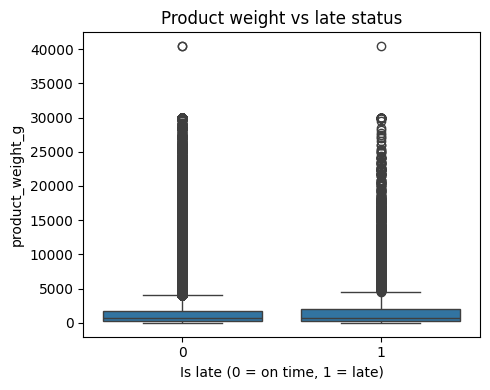

In [98]:
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=df_eda,
    x="is_late",
    y="product_weight_g",
)
plt.xlabel("Is late (0 = on time, 1 = late)")
plt.ylabel("product_weight_g")
plt.title("Product weight vs late status")
plt.tight_layout()
plt.show()

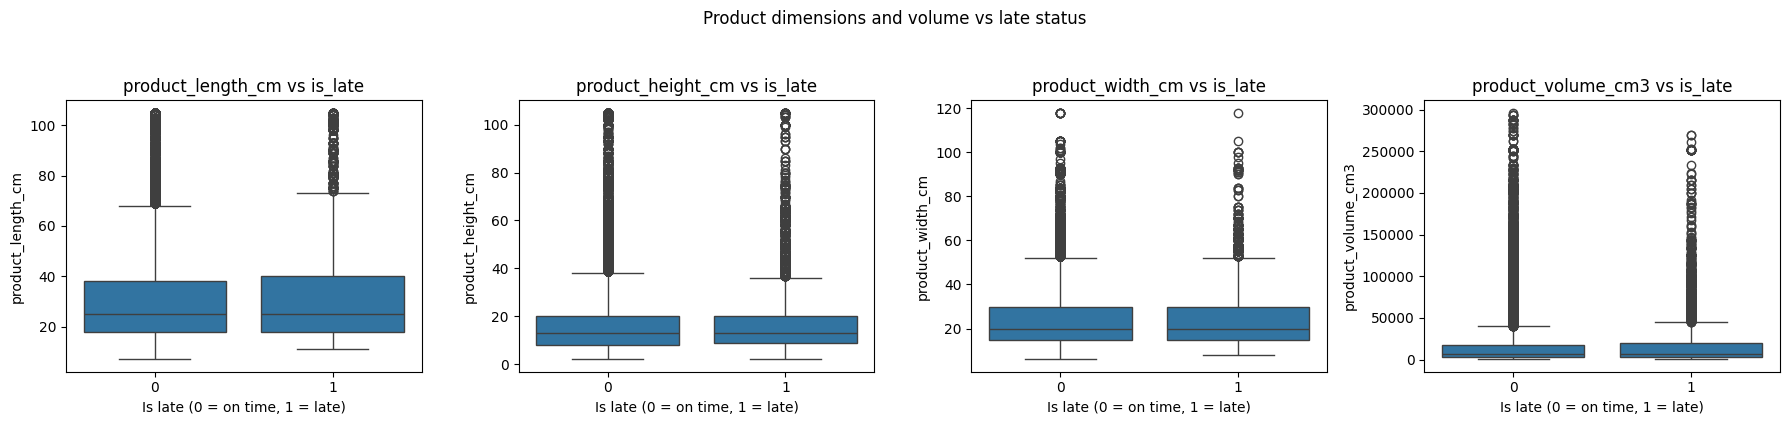

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=False)

features = [
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_volume_cm3",
]

for ax, feat in zip(axes, features):
    sns.boxplot(
        data=df_eda,
        x="is_late",
        y=feat,
        ax=ax
    )
    ax.set_xlabel("Is late (0 = on time, 1 = late)")
    ax.set_ylabel(feat)
    ax.set_title(f"{feat} vs is_late")

plt.suptitle("Product dimensions and volume vs late status", y=1.05)
plt.tight_layout()
plt.show()

In [100]:
bins = [0, 1e3, 5e3, 1e4, 5e4, 1e5, df_eda["product_volume_cm3"].max()]
labels = ["0–1k", "1k–5k", "5k–10k", "10k–50k", "50k–100k", "100k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

vol_late

,product_volume_bucket,total_orders,late_rate
0,0–1k,7828,0.077031
1,1k–5k,40081,0.078591
2,5k–10k,20339,0.073307
3,10k–50k,34706,0.080073
4,50k–100k,5685,0.093755
5,100k+,1539,0.103314


  product_volume_bucket  total_orders  late_rate
0                 0–500          1856   0.089440
1                500–1k          5972   0.073175
2                 1k–2k          9309   0.072618
3                 2k–5k         30772   0.080398
4                5k–10k         20339   0.073307
5               10k–20k         18169   0.079971
6               20k–50k         16537   0.080184
7              50k–100k          5685   0.093755
8                 100k+          1539   0.103314


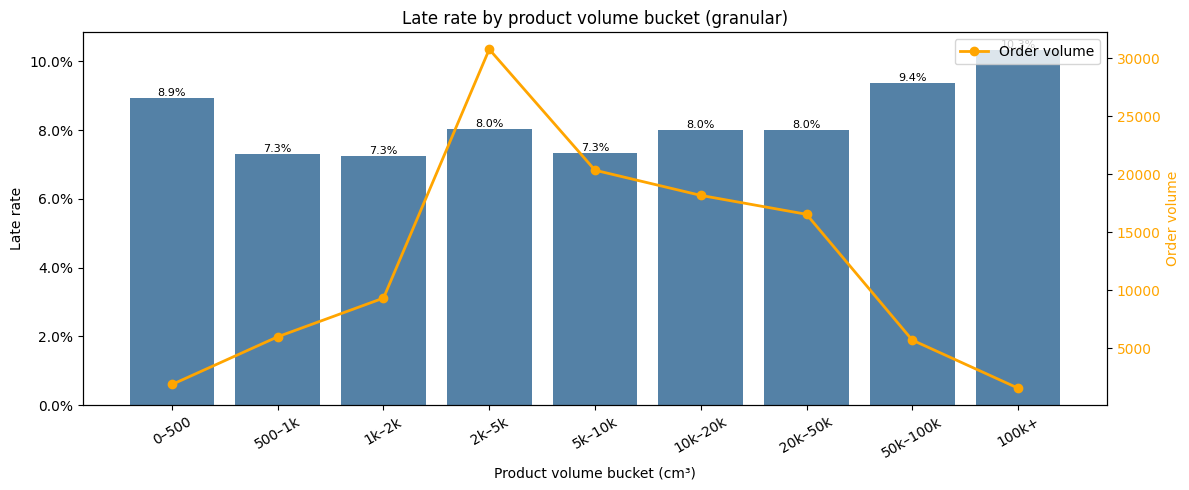

In [102]:
# Late rate by product volume bucket (more granular)
bins   = [0, 500, 1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5, df_eda["product_volume_cm3"].max()]
labels = ["0–500", "500–1k", "1k–2k", "2k–5k", "5k–10k", "10k–20k", "20k–50k", "50k–100k", "100k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(vol_late)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=vol_late,
    x="product_volume_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=8
    )

ax1.set_xlabel("Product volume bucket (cm³)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product volume bucket (granular)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(
    vol_late.index,
    vol_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

  product_volume_bucket  total_orders  late_rate
0                 0–50k        102954   0.077928
1                  50k+          7224   0.095792


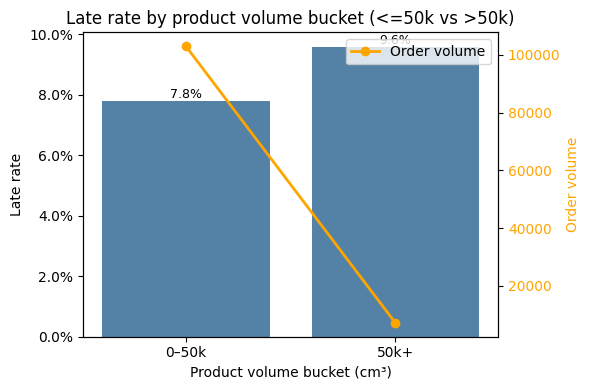

In [103]:
# Late rate by product volume bucket (2 buckets: <=50k and >50k cm³)
bins   = [0, 5e4, df_eda["product_volume_cm3"].max()]
labels = ["0–50k", "50k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late_2 = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(vol_late_2)

# Bar chart: late rate + volume line
fig, ax1 = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=vol_late_2,
    x="product_volume_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_xlabel("Product volume bucket (cm³)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product volume bucket (<=50k vs >50k)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    vol_late_2.index,
    vol_late_2["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


  product_weight_bucket  total_orders  late_rate
0                 0–10k        105023   0.077773
1                  10k+          5155   0.106111


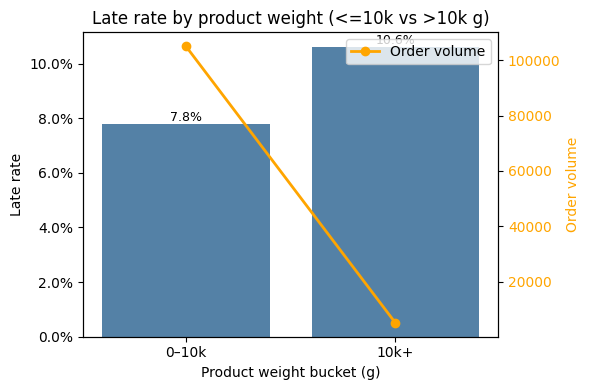

In [104]:
# Late rate by product weight bucket (2 buckets: <=10k and >10k g)
bins   = [0, 1e4, df_eda["product_weight_g"].max()]
labels = ["0–10k", "10k+"]

df_eda["product_weight_bucket"] = pd.cut(
    df_eda["product_weight_g"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

weight_late = (
    df_eda
    .groupby("product_weight_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(weight_late)

# Bar chart: late rate + volume line
fig, ax1 = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=weight_late,
    x="product_weight_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_xlabel("Product weight bucket (g)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product weight (<=10k vs >10k g)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    weight_late.index,
    weight_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()